# **2. Classification of natural disaster Tweets: Cleaning**

The dataset used in this project comes from the Disaster Tweets dataset, which contains a collection of tweets labeled according to whether they refer to a real disaster event or not. The goal of the dataset is to support the development of machine learning models capable of automatically identifying disaster-related information from social media posts.

In natural language processing tasks, raw text data often contains noise such as punctuation, links, mentions, and other elements that may not contribute meaningful information for machine learning models. Therefore, applying different **text preprocessing strategies** can help improve model performance by standardizing and simplifying the textual input.

In this project, three different preprocessing configurations were implemented and compared to evaluate their impact on the classification performance.



## 0. Imports

In [2]:
import re
import matplotlib.pyplot as plt
import pandas as pd
import sys
import os

## 1. Load dataset

In [61]:
df = pd.read_csv('train.csv')


## 2. Cleaning Data

### Null values

In [62]:
df.isnull().sum()

id             0
keyword       61
location    2533
text           0
target         0
dtype: int64

Text(0.5, 1.0, 'Top 10 Locations')

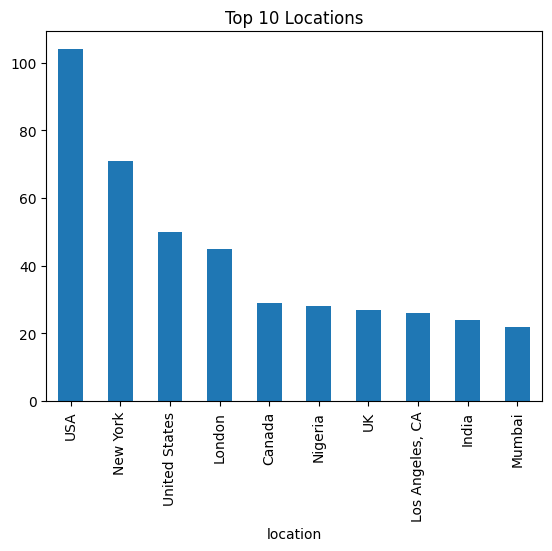

In [63]:
df['location'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Locations')

In [64]:
df['has_location'] = df['location'].notnull().astype(int)

#We will drop the 61 reegisters with null keyword
df = df.dropna(subset=['keyword'])
df = df.drop(columns=['id', 'location'])


In [65]:
df.isnull().sum()

keyword         0
text            0
target          0
has_location    0
dtype: int64

In [66]:
from html.parser import HTMLParser

class HTMLStripper(HTMLParser):
    def __init__(self):
        self.reset()
        self.strict = False
        self.convert_charrefs = True
        self.fed = []

    def handle_data(self, d):
        self.fed.append(d)

    def get_data(self):
        return ''.join(self.fed)

def remove_html(text):
    s = HTMLStripper()
    s.feed(text)
    return s.get_data()

In [67]:
def remove_emoji(text):
    emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"  # emoticons
                           u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                           u"\U0001F680-\U0001F6FF"  # transport & map symbols
                           u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                           u"\U00002702-\U000027B0"
                           u"\U000024C2-\U0001F251"
                           "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', text)

In [68]:
df['text'] = df['text'].apply(remove_html)
df['text'] = df['text'].apply(remove_emoji)

## **Configuration 1 – Basic Text Cleaning**

The first configuration applies a set of basic preprocessing steps aimed at standardizing the text and removing unnecessary elements. The following operations are performed:

* Conversion of all text to **lowercase** in order to avoid treating the same word with different capitalization as different tokens.
* **Removal of URLs**, since links generally do not provide useful semantic information for the classification task.
* **Removal of mentions** (e.g., `@username`), which typically refer to users rather than meaningful textual content.
* **Removal of punctuation marks**, such as commas, periods, and special characters, to simplify the text representation.

This configuration establishes a baseline preprocessing pipeline.



In [69]:
def cleaning_conf1(tweets):
    tweets = tweets.astype(str)
    cleaned_tweets = []

    for tweet in tweets:
        # lowercase
        tweet = tweet.lower()

        # Remove URLs
        tweet = re.sub(r'http\S+|www\S+|https\S+', '', tweet, flags=re.MULTILINE)

        # Remove mentions @ and '#' symbol
        tweet = re.sub(r'\@\w+|\#', '', tweet)

        # Remove punctuation and numbers
        tweet = re.sub(r'[^a-z\s]', '', tweet)

        cleaned_tweets.append(tweet)

    return cleaned_tweets


In [70]:
def save_cleaned_data(df, filename):
    path = 'Configurations_Data'
    if not os.path.exists(path):
        os.makedirs(path)
    df.to_csv(os.path.join(path, filename), index=False)
    print(f"Cleaned data saved to '{filename}' in the '{path}' directory.")

In [71]:
df1 = df.copy()
df1['text'] = cleaning_conf1(df1['text'])   

In [72]:
save_cleaned_data(df1, 'cleaned_data_conf1.csv')


Cleaned data saved to 'cleaned_data_conf1.csv' in the 'Configurations_Data' directory.


## **Configuration 2 – Removal of Stopwords**

The second configuration builds upon Configuration 1 and additionally removes **stopwords**. Stopwords are very common words in a language, such as *the*, *is*, *and*, and *to*, which typically appear frequently but carry limited semantic meaning for classification tasks. By removing these words, the model may focus more on informative terms related to disaster events.



In [73]:
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Ale\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [74]:
def cleaning_conf2(tweets):
    pre_tweets = cleaning_conf1(tweets)
    cleaned_tweets = []
    stop_words = set(stopwords.words('english'))

    for tweet in pre_tweets:
        filtered_words = []

        for word in tweet.split():
            if word not in stop_words:
                filtered_words.append(word)

        cleaned_tweets.append(" ".join(filtered_words))

    return cleaned_tweets

In [75]:
df2 = df.copy()
df2['text'] = cleaning_conf2(df2['text'])  

In [76]:
save_cleaned_data(df2,'cleaned_data_conf2.csv')

Cleaned data saved to 'cleaned_data_conf2.csv' in the 'Configurations_Data' directory.


## **Configuration 3 – Stemming or Lemmatization**

The third configuration also starts with the basic preprocessing steps from Configuration 1 but incorporates **stemming or lemmatization**. These techniques reduce words to their base or root form in order to normalize different variations of the same word.

* **Stemming** reduces words to a root form by removing suffixes (e.g., *running* → *run*).
* **Lemmatization** converts words to their dictionary form using linguistic rules (e.g., *better* → *good*).

Applying these techniques helps reduce vocabulary size and can improve the model’s ability to generalize by treating related word forms as the same feature.

The performance of the neural network model is then evaluated under each preprocessing configuration using metrics such as **accuracy** and **F1-score**, allowing for a comparison of how different text cleaning strategies influence classification results.


In [77]:
import nltk
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')
nltk.download('omw-1.4')


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Ale\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Ale\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [78]:
lematizer = WordNetLemmatizer()

def cleaning_conf3(tweets):
    pre_tweets = cleaning_conf1(tweets)
    cleaned_tweets = []

    for tweet in pre_tweets:
        lemmatized_words = []
        for word in tweet.split():
            lemmatized_words.append(lematizer.lemmatize(word))
        cleaned_tweets.append(" ".join(lemmatized_words))

    return cleaned_tweets

In [79]:
df3 = df.copy()
df3['text'] = cleaning_conf3(df3['text'])

In [ ]:
save_cleaned_data(df3,'cleaned_data_conf3.csv')

Cleaned data saved to 'cleaned_data_conf3.csv' in the 'Configurations_Data' directory.


: 